# Blood Cell Segmentation - Structured Notebook

This notebook demonstrates training and comparison of multiple segmentation architectures for blood cell segmentation from microscope images.

## Table of Contents
1. [Configuration](#configuration)
2. [Setup and Imports](#setup)
3. [Data Loading](#data-loading)
4. [Data Visualization](#data-visualization)
5. [Model Architectures](#model-architectures)
    - 5.1 [UNet](#unet)
    - 5.2 [Custom ResNet-based](#custom-resnet)
    - 5.3 [U-Net++](#unet-plus-plus)
    - 5.4 [UNetV2 (Attention U-Net)](#unetv2)
    - 5.5 [ResUNet](#resunet)
6. [Training Functions](#training-functions)
7. [Training All Models](#training-all-models)
8. [Evaluation Metrics Explanation](#evaluation-metrics)
9. [Model Evaluation](#evaluation)
10. [Model Comparison - ROC Curves](#model-comparison)
11. [Training Curves](#training-curves)
12. [Visual Results](#visual-results)
13. [Summary](#summary)

<a id='configuration'></a>
## 1. Configuration

In [4]:
CONFIG = {
    'dataset': '2',
    'img_size': 120,
    'batch_size': 32,
    'epochs': 50,
    'learning_rate': 1e-3,
    'base_filters': 32,
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Configuration:
  dataset: 2
  img_size: 120
  batch_size: 32
  epochs: 50
  learning_rate: 0.001
  base_filters: 32


<a id='setup'></a>
## 2. Setup and Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import accuracy_score, roc_curve, auc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


<a id='data-loading'></a>
## 3. Data Loading

In [ ]:


class BloodCellSegmentationDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        image = np.array(image, dtype=np.float32) / 255.0
        mask = np.array(mask, dtype=np.float32) / 255.0

        if self.transform:
            image = self.transform(image)

        image = torch.from_numpy(image).permute(2, 0, 1)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask


def load_dataset_in_memory(dataset_num, img_size=120):
    """
    Load dataset into memory with train/val/test split.

    Args:
        dataset_num: "1" or "2" to select which dataset to use
        img_size: target image size (will be resized to img_size x img_size)

    Returns:
        Tuple of (train_images, train_masks, val_images, val_masks, test_images, test_masks)
        Each containing tensors loaded in memory.
    """
    dataset_path = f"dataset/data{dataset_num}"

    if not os.path.exists(dataset_path):
        raise ValueError(f"Dataset path {dataset_path} does not exist")

    # Get all image files (assuming .bmp are images and .png are masks)
    image_files = sorted([f for f in os.listdir(dataset_path) if f.endswith(".bmp")])
    mask_files = sorted([f for f in os.listdir(dataset_path) if f.endswith(".png")])

    if len(image_files) != len(mask_files):
        raise ValueError(
            f"Mismatch between image count ({len(image_files)}) and mask count ({len(mask_files)})"
        )

    image_paths = [os.path.join(dataset_path, f) for f in image_files]
    mask_paths = [os.path.join(dataset_path, f) for f in mask_files]

    # Load images and masks into memory
    print(f"Loading {len(image_files)} images from dataset {dataset_num}...")
    images = []
    masks = []

    for img_path, mask_path in zip(image_paths, mask_paths):
        img = Image.open(img_path).convert("RGB")
        img = img.resize((img_size, img_size), Image.Resampling.LANCZOS)
        img = np.array(img, dtype=np.float32) / 255.0
        images.append(img)

        mask = Image.open(mask_path).convert("L")
        mask = mask.resize((img_size, img_size), Image.Resampling.LANCZOS)
        mask = np.array(mask, dtype=np.float32) / 255.0
        masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)

    # Split into train/val/test (70/15/15)
    # First split: 70% train, 30% temp
    indices = np.arange(len(images))
    train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42)

    # Second split: split 30% into val/test (50/50)
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

    train_images = torch.from_numpy(images[train_idx]).permute(0, 3, 1, 2)
    train_masks = torch.from_numpy(masks[train_idx]).unsqueeze(1)

    val_images = torch.from_numpy(images[val_idx]).permute(0, 3, 1, 2)
    val_masks = torch.from_numpy(masks[val_idx]).unsqueeze(1)

    test_images = torch.from_numpy(images[test_idx]).permute(0, 3, 1, 2)
    test_masks = torch.from_numpy(masks[test_idx]).unsqueeze(1)

    print(
        f"Dataset split: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(test_idx)}"
    )
    print(f"Train images shape: {train_images.shape}")
    print(f"Val images shape: {val_images.shape}")
    print(f"Test images shape: {test_images.shape}")

    return (
        train_images,
        train_masks,
        val_images,
        val_masks,
        test_images,
        test_masks,
    )


def get_data_loaders(train_images, train_masks, val_images, val_masks, batch_size=32):
    """
    Create PyTorch DataLoaders from in-memory tensors.

    Args:
        train_images: Training images tensor
        train_masks: Training masks tensor
        val_images: Validation images tensor
        val_masks: Validation masks tensor
        batch_size: Batch size for loaders

    Returns:
        Tuple of (train_loader, val_loader)
    """
    train_dataset = torch.utils.data.TensorDataset(train_images, train_masks)
    val_dataset = torch.utils.data.TensorDataset(val_images, val_masks)

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, num_workers=0
    )

    return train_loader, val_loader


In [ ]:
train_images, train_masks, val_images, val_masks, test_images, test_masks = load_dataset_in_memory(
    dataset_num=CONFIG['dataset'], img_size=CONFIG['img_size']
)

train_loader, val_loader = get_data_loaders(
    train_images, train_masks, val_images, val_masks, batch_size=CONFIG['batch_size']
)

print(f"Train: {train_images.shape}, Val: {val_images.shape}, Test: {test_images.shape}")

Loading 100 images from dataset 2...
Dataset split: Train=70, Val=15, Test=15
Train images shape: torch.Size([70, 3, 120, 120])
Val images shape: torch.Size([15, 3, 120, 120])
Test images shape: torch.Size([15, 3, 120, 120])
Train: torch.Size([70, 3, 120, 120]), Val: torch.Size([15, 3, 120, 120]), Test: torch.Size([15, 3, 120, 120])


<a id='data-visualization'></a>
## 4. Data Visualization

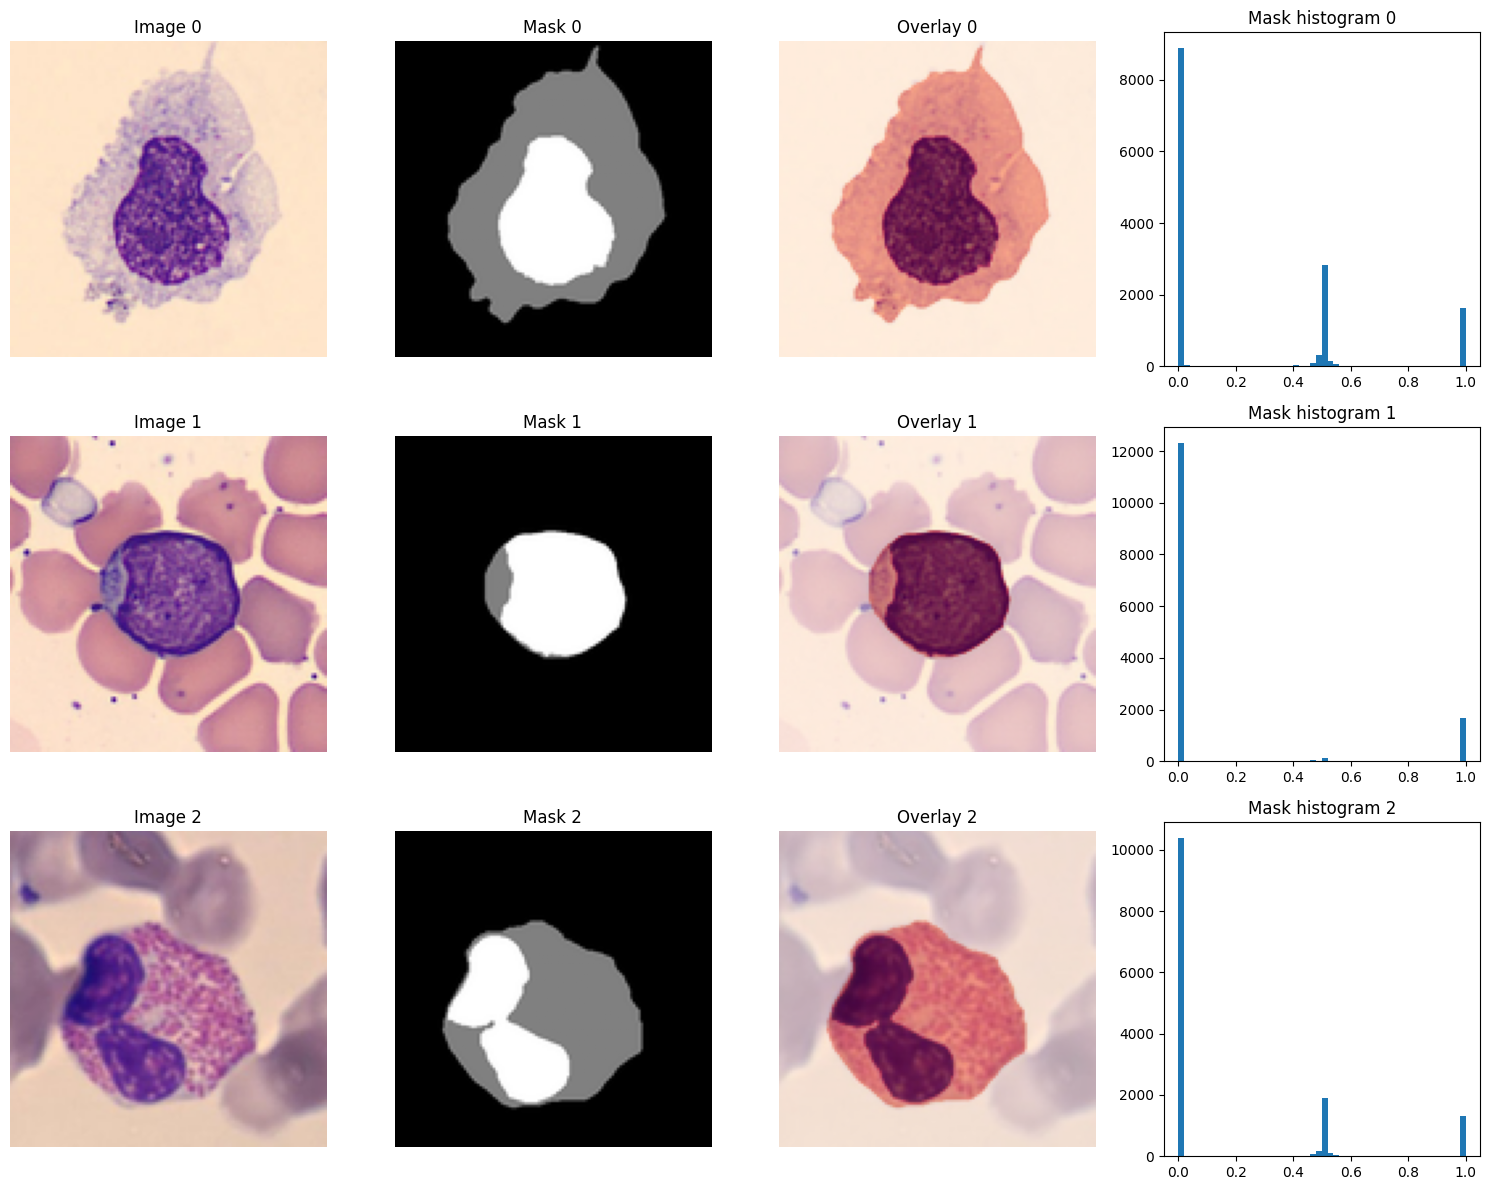

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(15, 12))
for i in range(3):
    img = train_images[i].permute(1, 2, 0).numpy()
    mask = train_masks[i, 0].numpy()
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Image {i}')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title(f'Mask {i}')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(img)
    axes[i, 2].imshow(mask, cmap='Reds', alpha=0.5)
    axes[i, 2].set_title(f'Overlay {i}')
    axes[i, 2].axis('off')
    axes[i, 3].hist(mask.flatten(), bins=50)
    axes[i, 3].set_title(f'Mask histogram {i}')
plt.tight_layout()
plt.show()

<a id='model-architectures'></a>
## 5. Model Architectures

<a id='unet'></a>
### 5.1 UNet

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_filters=32):
        super(UNet, self).__init__()
        self.base_filters = base_filters

        # Encoder (Downsampling)
        self.enc1 = DoubleConv(in_channels, base_filters)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = DoubleConv(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc3 = DoubleConv(base_filters * 2, base_filters * 4)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc4 = DoubleConv(base_filters * 4, base_filters * 8)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(base_filters * 8, base_filters * 16)

        # Decoder (Upsampling)
        self.upconv4 = nn.ConvTranspose2d(
            base_filters * 16, base_filters * 8, kernel_size=2, stride=2
        )
        self.dec4 = DoubleConv(base_filters * 16, base_filters * 8)

        self.upconv3 = nn.ConvTranspose2d(
            base_filters * 8, base_filters * 4, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(base_filters * 8, base_filters * 4)

        self.upconv2 = nn.ConvTranspose2d(
            base_filters * 4, base_filters * 2, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(base_filters * 4, base_filters * 2)

        self.upconv1 = nn.ConvTranspose2d(
            base_filters * 2, base_filters, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(base_filters * 2, base_filters)

        # Output layer
        self.out_conv = nn.Conv2d(base_filters, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        x = self.pool1(enc1)

        enc2 = self.enc2(x)
        x = self.pool2(enc2)

        enc3 = self.enc3(x)
        x = self.pool3(enc3)

        enc4 = self.enc4(x)
        x = self.pool4(enc4)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder with proper size handling
        x = self.upconv4(x)
        # Crop skip connection if needed
        if x.shape != enc4.shape:
            x = F.interpolate(x, size=enc4.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc4], dim=1)
        x = self.dec4(x)

        x = self.upconv3(x)
        if x.shape != enc3.shape:
            x = F.interpolate(x, size=enc3.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc3], dim=1)
        x = self.dec3(x)

        x = self.upconv2(x)
        if x.shape != enc2.shape:
            x = F.interpolate(x, size=enc2.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc2], dim=1)
        x = self.dec2(x)

        x = self.upconv1(x)
        if x.shape != enc1.shape:
            x = F.interpolate(x, size=enc1.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, enc1], dim=1)
        x = self.dec1(x)

        # Output
        x = self.out_conv(x)
        return x


In [ ]:
unet_model = UNet(in_channels=3, out_channels=1, base_filters=CONFIG['base_filters']).to(device)
unet_params = sum(p.numel() for p in unet_model.parameters())
print(f"UNet: {unet_params:,} parameters")

UNet: 7,765,985 parameters


<a id='custom-resnet'></a>
### 5.2 Custom ResNet-based Model

In [10]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.skip = nn.Identity() if in_channels == out_channels else nn.Conv2d(in_channels, out_channels, kernel_size=1)
    
    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class CustomSegmentationNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_filters=32):
        super(CustomSegmentationNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(in_channels, base_filters, 3, padding=1), nn.BatchNorm2d(base_filters), nn.ReLU(inplace=True), ResidualBlock(base_filters, base_filters))
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResidualBlock(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResidualBlock(base_filters * 2, base_filters * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResidualBlock(base_filters * 4, base_filters * 8)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(ResidualBlock(base_filters * 8, base_filters * 16), ResidualBlock(base_filters * 16, base_filters * 16))
        self.up4 = nn.ConvTranspose2d(base_filters * 16, base_filters * 8, 2, stride=2)
        self.dec4 = ResidualBlock(base_filters * 16, base_filters * 8)
        self.up3 = nn.ConvTranspose2d(base_filters * 8, base_filters * 4, 2, stride=2)
        self.dec3 = ResidualBlock(base_filters * 8, base_filters * 4)
        self.up2 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, 2, stride=2)
        self.dec2 = ResidualBlock(base_filters * 4, base_filters * 2)
        self.up1 = nn.ConvTranspose2d(base_filters * 2, base_filters, 2, stride=2)
        self.dec1 = ResidualBlock(base_filters * 2, base_filters)
        self.out_conv = nn.Conv2d(base_filters, out_channels, 1)
    
    def _crop_concat(self, upsampled, encoder):
        dH = encoder.size(2) - upsampled.size(2)
        dW = encoder.size(3) - upsampled.size(3)
        if dH > 0 or dW > 0:
            encoder = encoder[:, :, dH//2:encoder.size(2)-dH//2-dH%2, dW//2:encoder.size(3)-dW//2-dW%2]
        return torch.cat([upsampled, encoder], dim=1)
    
    def forward(self, x):
        input_size = x.size()[2:]
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))
        d4 = self.dec4(self._crop_concat(self.up4(b), e4))
        d3 = self.dec3(self._crop_concat(self.up3(d4), e3))
        d2 = self.dec2(self._crop_concat(self.up2(d3), e2))
        d1 = self.dec1(self._crop_concat(self.up1(d2), e1))
        out = self.out_conv(d1)
        if out.size()[2:] != input_size:
            out = torch.nn.functional.interpolate(out, size=input_size, mode='bilinear', align_corners=False)
        return out

custom_model = CustomSegmentationNet(in_channels=3, out_channels=1, base_filters=CONFIG['base_filters']).to(device)
custom_params = sum(p.numel() for p in custom_model.parameters())
print(f"Custom Model: {custom_params:,} parameters")

Custom Model: 12,846,561 parameters


<a id='unet-plus-plus'></a>
### 5.3 U-Net++

In [11]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class UNetPlusPlus(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_filters=32):
        super(UNetPlusPlus, self).__init__()
        filters = [base_filters, base_filters*2, base_filters*4, base_filters*8, base_filters*16]
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        self.conv0_0 = ConvBlock(in_channels, filters[0])
        self.conv1_0 = ConvBlock(filters[0], filters[1])
        self.conv2_0 = ConvBlock(filters[1], filters[2])
        self.conv3_0 = ConvBlock(filters[2], filters[3])
        self.conv4_0 = ConvBlock(filters[3], filters[4])
        
        self.conv0_1 = ConvBlock(filters[0] + filters[1], filters[0])
        self.conv1_1 = ConvBlock(filters[1] + filters[2], filters[1])
        self.conv2_1 = ConvBlock(filters[2] + filters[3], filters[2])
        self.conv3_1 = ConvBlock(filters[3] + filters[4], filters[3])
        
        self.conv0_2 = ConvBlock(filters[0]*2 + filters[1], filters[0])
        self.conv1_2 = ConvBlock(filters[1]*2 + filters[2], filters[1])
        self.conv2_2 = ConvBlock(filters[2]*2 + filters[3], filters[2])
        
        self.conv0_3 = ConvBlock(filters[0]*3 + filters[1], filters[0])
        self.conv1_3 = ConvBlock(filters[1]*3 + filters[2], filters[1])
        
        self.conv0_4 = ConvBlock(filters[0]*4 + filters[1], filters[0])
        self.final = nn.Conv2d(filters[0], out_channels, 1)
    
    def _match_size(self, x, target):
        if x.size()[2:] != target.size()[2:]:
            x = torch.nn.functional.interpolate(x, size=target.size()[2:], mode='bilinear', align_corners=False)
        return x
    
    def forward(self, x):
        input_size = x.size()[2:]
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x2_0 = self.conv2_0(self.pool(x1_0))
        x3_0 = self.conv3_0(self.pool(x2_0))
        x4_0 = self.conv4_0(self.pool(x3_0))
        
        x0_1 = self.conv0_1(torch.cat([x0_0, self._match_size(self.up(x1_0), x0_0)], 1))
        x1_1 = self.conv1_1(torch.cat([x1_0, self._match_size(self.up(x2_0), x1_0)], 1))
        x2_1 = self.conv2_1(torch.cat([x2_0, self._match_size(self.up(x3_0), x2_0)], 1))
        x3_1 = self.conv3_1(torch.cat([x3_0, self._match_size(self.up(x4_0), x3_0)], 1))
        
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self._match_size(self.up(x1_1), x0_0)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self._match_size(self.up(x2_1), x1_0)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self._match_size(self.up(x3_1), x2_0)], 1))
        
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self._match_size(self.up(x1_2), x0_0)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self._match_size(self.up(x2_2), x1_0)], 1))
        
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self._match_size(self.up(x1_3), x0_0)], 1))
        
        output = self.final(x0_4)
        if output.size()[2:] != input_size:
            output = torch.nn.functional.interpolate(output, size=input_size, mode='bilinear', align_corners=False)
        return output

unetpp_model = UNetPlusPlus(in_channels=3, out_channels=1, base_filters=CONFIG['base_filters']).to(device)
unetpp_params = sum(p.numel() for p in unetpp_model.parameters())
print(f"U-Net++: {unetpp_params:,} parameters")

U-Net++: 9,163,329 parameters


<a id='unetv2'></a>
### 5.4 UNetV2 (Attention U-Net)

In [12]:
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True), nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, g, x):
        if g.size()[2:] != x.size()[2:]:
            g = torch.nn.functional.interpolate(g, size=x.size()[2:], mode='bilinear', align_corners=False)
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        return x * self.psi(self.relu(g1 + x1))


class UNetV2(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_filters=32):
        super(UNetV2, self).__init__()
        self.enc1 = ConvBlock(in_channels, base_filters)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(base_filters * 2, base_filters * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ConvBlock(base_filters * 4, base_filters * 8)
        self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = ConvBlock(base_filters * 8, base_filters * 16)
        
        self.up4 = nn.ConvTranspose2d(base_filters * 16, base_filters * 8, 2, stride=2)
        self.att4 = AttentionBlock(base_filters * 8, base_filters * 8, base_filters * 4)
        self.dec4 = ConvBlock(base_filters * 16, base_filters * 8)
        
        self.up3 = nn.ConvTranspose2d(base_filters * 8, base_filters * 4, 2, stride=2)
        self.att3 = AttentionBlock(base_filters * 4, base_filters * 4, base_filters * 2)
        self.dec3 = ConvBlock(base_filters * 8, base_filters * 4)
        
        self.up2 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, 2, stride=2)
        self.att2 = AttentionBlock(base_filters * 2, base_filters * 2, base_filters)
        self.dec2 = ConvBlock(base_filters * 4, base_filters * 2)
        
        self.up1 = nn.ConvTranspose2d(base_filters * 2, base_filters, 2, stride=2)
        self.att1 = AttentionBlock(base_filters, base_filters, base_filters // 2)
        self.dec1 = ConvBlock(base_filters * 2, base_filters)
        
        self.out_conv = nn.Conv2d(base_filters, out_channels, 1)
    
    def _match_size(self, x, target):
        if x.size()[2:] != target.size()[2:]:
            x = torch.nn.functional.interpolate(x, size=target.size()[2:], mode='bilinear', align_corners=False)
        return x
    
    def forward(self, x):
        input_size = x.size()[2:]
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))
        
        d4 = self.up4(b)
        e4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, self._match_size(e4, d4)], 1))
        
        d3 = self.up3(d4)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, self._match_size(e3, d3)], 1))
        
        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, self._match_size(e2, d2)], 1))
        
        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, self._match_size(e1, d1)], 1))
        
        output = self.out_conv(d1)
        if output.size()[2:] != input_size:
            output = torch.nn.functional.interpolate(output, size=input_size, mode='bilinear', align_corners=False)
        return output

unetv2_model = UNetV2(in_channels=3, out_channels=1, base_filters=CONFIG['base_filters']).to(device)
unetv2_params = sum(p.numel() for p in unetv2_model.parameters())
print(f"UNetV2: {unetv2_params:,} parameters")

UNetV2: 7,854,717 parameters


<a id='resunet'></a>
### 5.5 ResUNet

In [13]:
class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.residual = nn.Sequential(nn.Conv2d(in_channels, out_channels, 1, stride=stride), nn.BatchNorm2d(out_channels)) if stride != 1 or in_channels != out_channels else nn.Identity()
    
    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.residual(x))


class ResUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_filters=32):
        super(ResUNet, self).__init__()
        self.input_conv = nn.Sequential(nn.Conv2d(in_channels, base_filters, 3, padding=1), nn.BatchNorm2d(base_filters), nn.ReLU(inplace=True))
        
        self.enc1 = ResidualConvBlock(base_filters, base_filters)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResidualConvBlock(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResidualConvBlock(base_filters * 2, base_filters * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResidualConvBlock(base_filters * 4, base_filters * 8)
        self.pool4 = nn.MaxPool2d(2)
        
        self.bridge = nn.Sequential(ResidualConvBlock(base_filters * 8, base_filters * 16), ResidualConvBlock(base_filters * 16, base_filters * 16))
        
        self.up4 = nn.ConvTranspose2d(base_filters * 16, base_filters * 8, 2, stride=2)
        self.dec4 = ResidualConvBlock(base_filters * 16, base_filters * 8)
        self.up3 = nn.ConvTranspose2d(base_filters * 8, base_filters * 4, 2, stride=2)
        self.dec3 = ResidualConvBlock(base_filters * 8, base_filters * 4)
        self.up2 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, 2, stride=2)
        self.dec2 = ResidualConvBlock(base_filters * 4, base_filters * 2)
        self.up1 = nn.ConvTranspose2d(base_filters * 2, base_filters, 2, stride=2)
        self.dec1 = ResidualConvBlock(base_filters * 2, base_filters)
        
        self.out_conv = nn.Conv2d(base_filters, out_channels, 1)
    
    def _match_size(self, x, target):
        if x.size()[2:] != target.size()[2:]:
            x_h, x_w = x.size()[2:]
            t_h, t_w = target.size()[2:]
            if x_h >= t_h and x_w >= t_w:
                dH = x_h - t_h
                dW = x_w - t_w
                x = x[:, :, dH//2:x_h-dH//2-dH%2, dW//2:x_w-dW//2-dW%2]
            else:
                x = torch.nn.functional.interpolate(x, size=target.size()[2:], mode='bilinear', align_corners=False)
        return x
    
    def forward(self, x):
        input_size = x.size()[2:]
        x = self.input_conv(x)
        
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bridge(self.pool4(e4))
        
        d4 = self.dec4(torch.cat([self._match_size(self.up4(b), e4), e4], 1))
        d3 = self.dec3(torch.cat([self._match_size(self.up3(d4), e3), e3], 1))
        d2 = self.dec2(torch.cat([self._match_size(self.up2(d3), e2), e2], 1))
        d1 = self.dec1(torch.cat([self._match_size(self.up1(d2), e1), e1], 1))
        
        output = self.out_conv(d1)
        if output.size()[2:] != input_size:
            output = torch.nn.functional.interpolate(output, size=input_size, mode='bilinear', align_corners=False)
        return output

resunet_model = ResUNet(in_channels=3, out_channels=1, base_filters=CONFIG['base_filters']).to(device)
resunet_params = sum(p.numel() for p in resunet_model.parameters())
print(f"ResUNet: {resunet_params:,} parameters")

ResUNet: 12,849,441 parameters


### Model Architecture Summary

In [14]:
print("=" * 60)
print("MODEL ARCHITECTURE COMPARISON")
print("=" * 60)
print(f"{'Model':<20} {'Parameters':>15}")
print("-" * 60)
print(f"{'UNet':<20} {unet_params:>15,}")
print(f"{'Custom Model':<20} {custom_params:>15,}")
print(f"{'U-Net++':<20} {unetpp_params:>15,}")
print(f"{'UNetV2':<20} {unetv2_params:>15,}")
print(f"{'ResUNet':<20} {resunet_params:>15,}")
print("=" * 60)

MODEL ARCHITECTURE COMPARISON
Model                     Parameters
------------------------------------------------------------
UNet                       7,765,985
Custom Model              12,846,561
U-Net++                    9,163,329
UNetV2                     7,854,717
ResUNet                   12,849,441


<a id='training-functions'></a>
## 6. Training Functions

In [15]:
def calculate_iou(pred, target, threshold=0.5):
    """Calculate Intersection over Union (IoU) metric."""
    pred_binary = (pred > threshold).float()
    intersection = (pred_binary * target).sum((1, 2, 3))
    union = ((pred_binary + target) > 0).float().sum((1, 2, 3))
    return (intersection / (union + 1e-6)).mean()


def train_model(model, train_loader, val_loader, epochs, learning_rate, device, model_name="Model"):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    best_val_loss = float('inf')
    train_losses, val_losses, val_ious = [], [], []
    
    print(f"Training {model_name} for {epochs} epochs...")
    
    for epoch in tqdm(range(epochs), desc=model_name):
        model.train()
        train_loss = 0.0
        for batch_imgs, batch_masks in train_loader:
            batch_imgs, batch_masks = batch_imgs.to(device), batch_masks.to(device)
            optimizer.zero_grad()
            outputs = model(batch_imgs)
            loss = criterion(outputs, batch_masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss, val_iou = 0.0, 0.0
        with torch.no_grad():
            for batch_imgs, batch_masks in val_loader:
                batch_imgs, batch_masks = batch_imgs.to(device), batch_masks.to(device)
                outputs = model(batch_imgs)
                val_loss += criterion(outputs, batch_masks).item()
                val_iou += calculate_iou(torch.sigmoid(outputs), batch_masks).item()
        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        val_losses.append(val_loss)
        val_ious.append(val_iou)
        
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'{model_name.lower()}_best.pth')
    
    model.load_state_dict(torch.load(f'{model_name.lower()}_best.pth', map_location=device))
    return model, train_losses, val_losses, val_ious


def evaluate_model(model, test_images, test_masks, device):
    """Evaluate model on test set and return multiple metrics."""
    model.eval()
    all_preds, all_masks_list, all_probs = [], [], []
    
    with torch.no_grad():
        for i in range(len(test_images)):
            test_img = test_images[i:i+1].to(device)
            test_mask = test_masks[i:i+1].to(device)
            pred = model(test_img)
            pred_prob = torch.sigmoid(pred).cpu().numpy().flatten()
            pred_binary = (pred_prob > 0.5).astype(int)
            mask_binary = (test_mask.cpu().numpy().flatten() > 0.5).astype(int)
            all_probs.extend(pred_prob)
            all_preds.extend(pred_binary)
            all_masks_list.extend(mask_binary)
    
    all_preds = np.array(all_preds)
    all_masks_list = np.array(all_masks_list)
    all_probs = np.array(all_probs)
    
    # Accuracy
    accuracy = accuracy_score(all_masks_list, all_preds)
    
    # IoU (Intersection over Union)
    intersection = (all_preds * all_masks_list).sum()
    union = ((all_preds + all_masks_list) > 0).sum()
    iou = intersection / (union + 1e-6)
    
    # Dice Coefficient
    dice = 2 * intersection / (all_preds.sum() + all_masks_list.sum() + 1e-6)
    
    # ROC/AUC
    fpr, tpr, _ = roc_curve(all_masks_list, all_probs)
    roc_auc = auc(fpr, tpr)
    
    return {
        'accuracy': accuracy,
        'iou': iou,
        'dice': dice,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr
    }

<a id='training-all-models'></a>
## 7. Training All Models

In [16]:
models = {
    'UNet': unet_model,
    'Custom': custom_model,
    'U-Net++': unetpp_model,
    'UNetV2': unetv2_model,
    'ResUNet': resunet_model
}

results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"TRAINING {name.upper()}")
    print(f"{'='*60}")
    
    trained_model, train_losses, val_losses, val_ious = train_model(
        model, train_loader, val_loader,
        epochs=CONFIG['epochs'],
        learning_rate=CONFIG['learning_rate'],
        device=device,
        model_name=name
    )
    
    # Evaluate model
    metrics = evaluate_model(trained_model, test_images, test_masks, device)
    results[name] = {
        'model': trained_model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_ious': val_ious,
        **metrics
    }
    
    print(f"{name} - Accuracy: {metrics['accuracy']:.4f}, IoU: {metrics['iou']:.4f}, AUC: {metrics['auc']:.4f}")


TRAINING UNET
Training UNet for 50 epochs...


UNet: 100%|██████████| 50/50 [00:21<00:00,  2.38it/s]


UNet - Accuracy: 0.8896, IoU: 0.5238, AUC: 0.9841

TRAINING CUSTOM
Training Custom for 50 epochs...


Custom: 100%|██████████| 50/50 [00:23<00:00,  2.14it/s]


Custom - Accuracy: 0.9334, IoU: 0.7241, AUC: 0.9857

TRAINING U-NET++
Training U-Net++ for 50 epochs...


...

U-Net++ - Accuracy: 0.8836, IoU: 0.4935, AUC: 0.9756

TRAINING UNETV2
Training UNetV2 for 50 epochs...


UNetV2: 100%|██████████| 50/50 [00:22<00:00,  2.19it/s]


UNetV2 - Accuracy: 0.8864, IoU: 0.5141, AUC: 0.9625

TRAINING RESUNET
Training ResUNet for 50 epochs...


ResUNet: 100%|██████████| 50/50 [00:25<00:00,  1.94it/s]

ResUNet - Accuracy: 0.9135, IoU: 0.6371, AUC: 0.9839


<a id='evaluation-metrics'></a>
## 8. Evaluation Metrics Explanation

This section explains the metrics used to evaluate our segmentation models.

### 8.1 Intersection over Union (IoU)

**IoU** (also known as Jaccard Index) is the primary metric for semantic segmentation. It measures the overlap between predicted and ground truth segmentation.

**Formula**: $$\text{IoU} = \frac{\text{Intersection}}{\text{Union}} = \frac{TP}{TP + FP + FN}$$

Where:
- **TP (True Positive)**: Correctly predicted foreground pixels
- **FP (False Positive)**: Incorrectly predicted foreground pixels
- **FN (False Negative)**: Missed ground truth pixels

**Interpretation**:
- IoU = 1.0: Perfect segmentation
- IoU = 0: No overlap
- IoU > 0.5: Generally good
- IoU > 0.7: Excellent

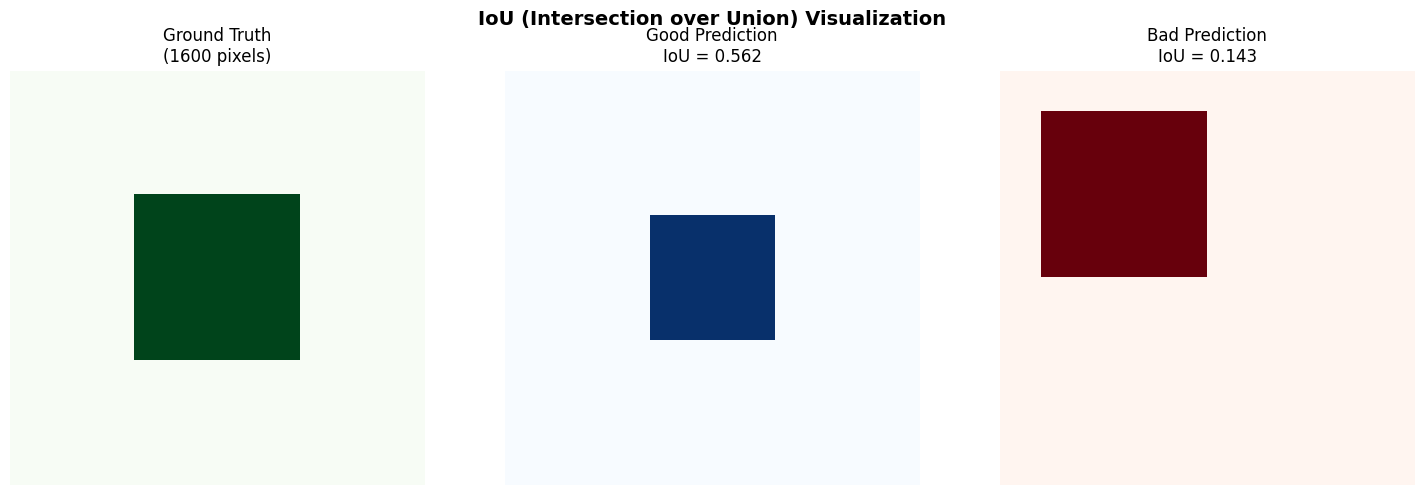

In [17]:
# Visual explanation of IoU
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gt = np.zeros((100, 100))
gt[30:70, 30:70] = 1

pred_good = np.zeros((100, 100))
pred_good[35:65, 35:65] = 1

pred_bad = np.zeros((100, 100))
pred_bad[10:50, 10:50] = 1

intersection_good = (gt * pred_good).sum()
union_good = ((gt + pred_good) > 0).sum()
iou_good = intersection_good / union_good

intersection_bad = (gt * pred_bad).sum()
union_bad = ((gt + pred_bad) > 0).sum()
iou_bad = intersection_bad / union_bad

axes[0].imshow(gt, cmap='Greens', vmin=0, vmax=1)
axes[0].set_title(f'Ground Truth\n(1600 pixels)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(pred_good, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title(f'Good Prediction\nIoU = {iou_good:.3f}', fontsize=12)
axes[1].axis('off')

axes[2].imshow(pred_bad, cmap='Reds', vmin=0, vmax=1)
axes[2].set_title(f'Bad Prediction\nIoU = {iou_bad:.3f}', fontsize=12)
axes[2].axis('off')

plt.suptitle('IoU (Intersection over Union) Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Dice Coefficient

**Dice Coefficient** is closely related to IoU and is commonly used in medical imaging.

**Formula**: $$\text{Dice} = \frac{2 \times |A \cap B|}{|A| + |B|} = \frac{2 \times TP}{2 \times TP + FP + FN}$$

**Relationship with IoU**: $$\text{Dice} = \frac{2 \times \text{IoU}}{1 + \text{IoU}}$$

**Note**: Dice is always >= IoU. When IoU = 0.5, Dice = 0.667

### 8.3 Accuracy and ROC/AUC

**Accuracy**: Proportion of correctly classified pixels (both foreground and background).

**ROC Curve**: Plots True Positive Rate vs False Positive Rate at different thresholds.

**AUC (Area Under ROC Curve)**: Threshold-independent measure of classification ability.
- AUC = 0.5: Random classifier
- AUC = 1.0: Perfect classifier

### 8.4 Metrics Summary

| Metric | Range | Best | Use Case |
|--------|-------|------|----------|
| **IoU** | 0-1 | 1.0 | Primary segmentation metric |
| **Dice** | 0-1 | 1.0 | Medical imaging, balanced with IoU |
| **Accuracy** | 0-1 | 1.0 | Quick overview (can be misleading) |
| **AUC** | 0-1 | 1.0 | Threshold-independent comparison |

<a id='evaluation'></a>
## 9. Model Evaluation

In [18]:
print("\n" + "=" * 90)
print("COMPREHENSIVE MODEL COMPARISON - TEST SET RESULTS")
print("=" * 90)
print(f"{'Model':<15} {'Accuracy':>10} {'IoU':>10} {'Dice':>10} {'AUC':>10} {'Parameters':>15}")
print("-" * 90)

model_params = {'UNet': unet_params, 'Custom': custom_params, 'U-Net++': unetpp_params, 'UNetV2': unetv2_params, 'ResUNet': resunet_params}

for name, res in results.items():
    print(f"{name:<15} {res['accuracy']:>10.4f} {res['iou']:>10.4f} {res['dice']:>10.4f} {res['auc']:>10.4f} {model_params[name]:>15,}")

print("=" * 90)

best_iou_model = max(results.items(), key=lambda x: x[1]['iou'])
best_dice_model = max(results.items(), key=lambda x: x[1]['dice'])
best_acc_model = max(results.items(), key=lambda x: x[1]['accuracy'])

print(f"\nBest IoU:   {best_iou_model[0]} = {best_iou_model[1]['iou']:.4f}")
print(f"Best Dice:   {best_dice_model[0]} = {best_dice_model[1]['dice']:.4f}")
print(f"Best Acc:    {best_acc_model[0]} = {best_acc_model[1]['accuracy']:.4f}")
print(f"Best AUC:    {max(results.items(), key=lambda x: x[1]['auc'])[0]} = {max(results.items(), key=lambda x: x[1]['auc'])[1]['auc']:.4f}")


COMPREHENSIVE MODEL COMPARISON - TEST SET RESULTS
Model             Accuracy        IoU       Dice        AUC      Parameters
------------------------------------------------------------------------------------------
UNet                0.8896     0.5238     0.6875     0.9841       7,765,985
Custom              0.9334     0.7241     0.8400     0.9857      12,846,561
U-Net++             0.8836     0.4935     0.6609     0.9756       9,163,329
UNetV2              0.8864     0.5141     0.6790     0.9625       7,854,717
ResUNet             0.9135     0.6371     0.7783     0.9839      12,849,441

Best IoU:   Custom = 0.7241
Best Dice:   Custom = 0.8400
Best Acc:    Custom = 0.9334
Best AUC:    Custom = 0.9857


<a id='model-comparison'></a>
## 10. Model Comparison - ROC Curves

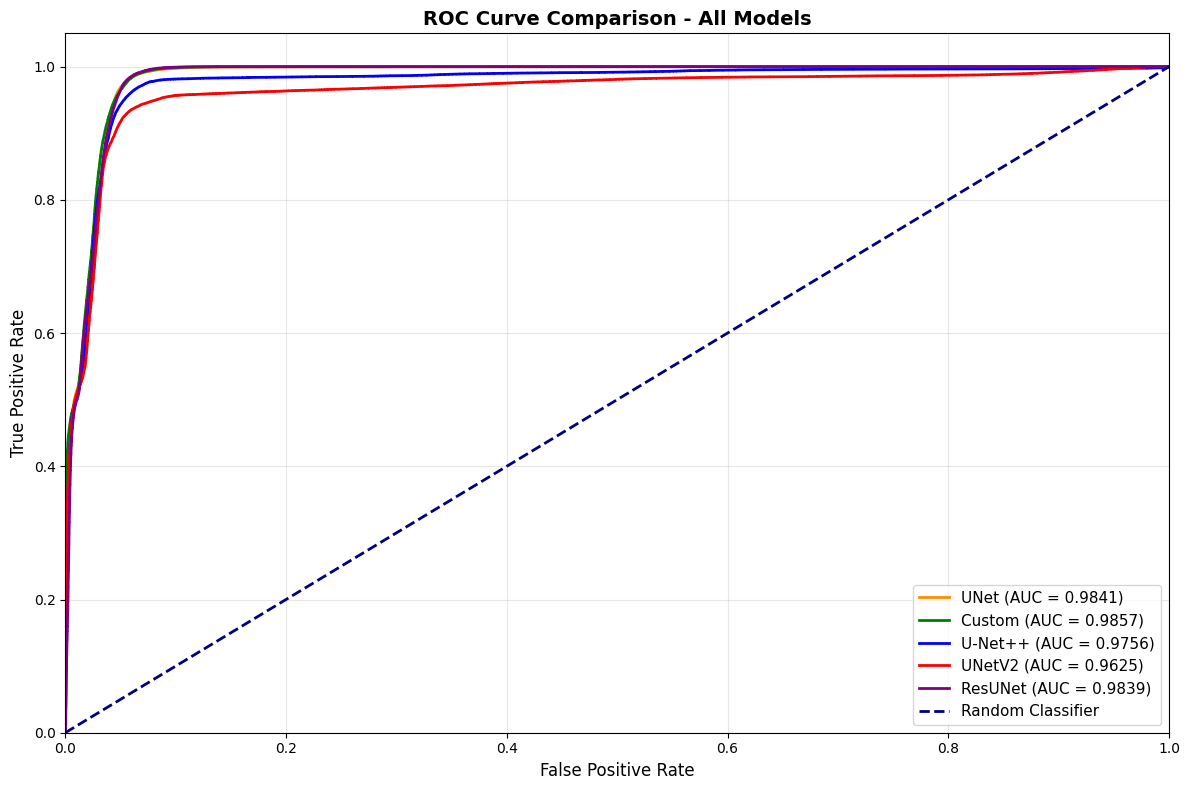

In [19]:
plt.figure(figsize=(12, 8))
colors = ['darkorange', 'green', 'blue', 'red', 'purple']

for i, (name, res) in enumerate(results.items()):
    plt.plot(res['fpr'], res['tpr'], color=colors[i], lw=2, label=f"{name} (AUC = {res['auc']:.4f})")

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - All Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='training-curves'></a>
## 11. Training Curves

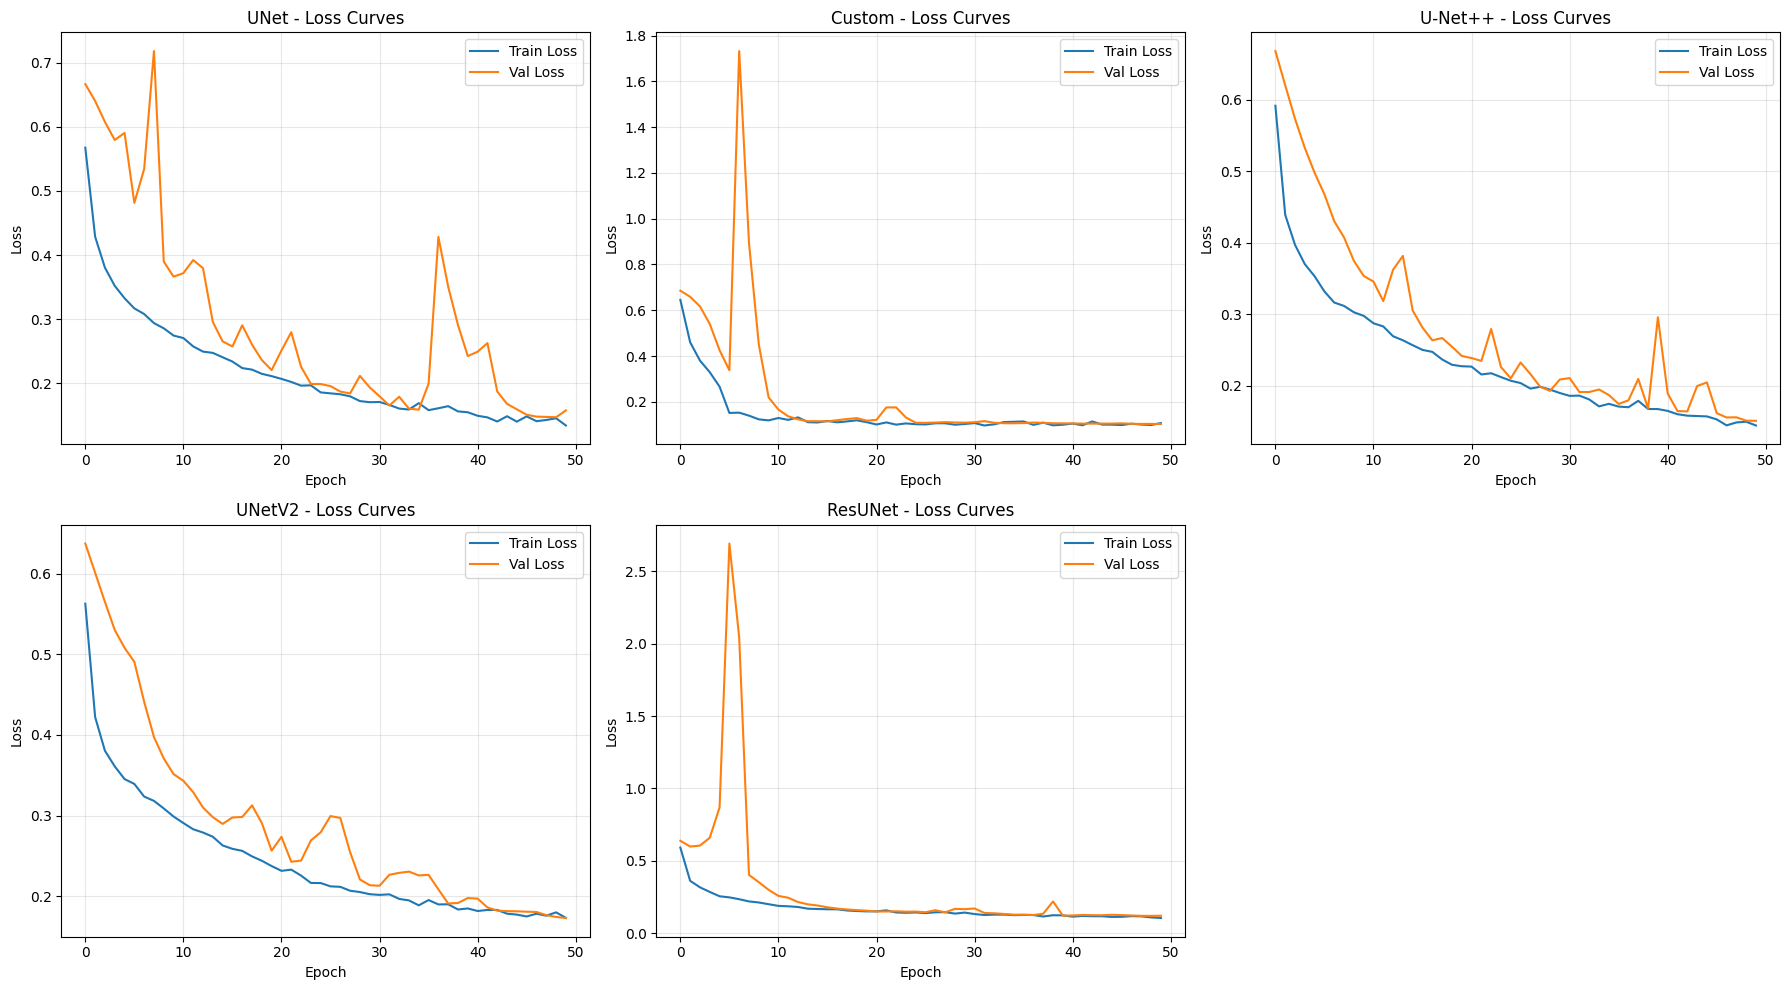

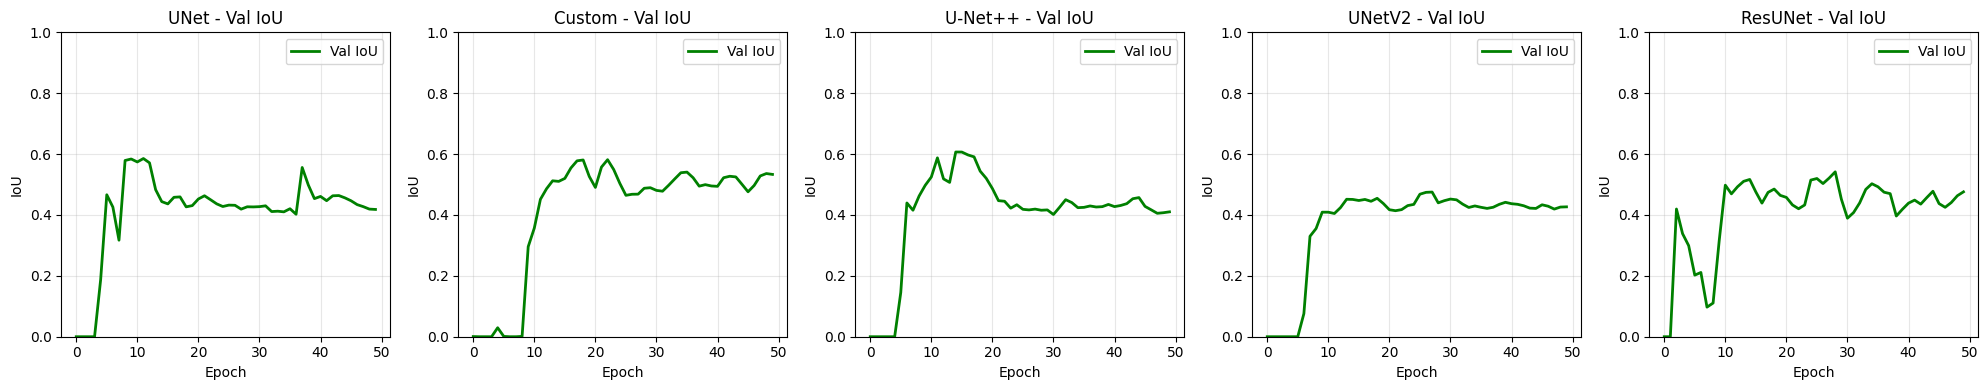

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    axes[i].plot(res['train_losses'], label='Train Loss')
    axes[i].plot(res['val_losses'], label='Val Loss')
    axes[i].set_title(f'{name} - Loss Curves', fontsize=12)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[5].axis('off')
plt.tight_layout()
plt.show()

# IoU curves
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, (name, res) in enumerate(results.items()):
    axes[i].plot(res['val_ious'], label='Val IoU', color='green', linewidth=2)
    axes[i].set_title(f'{name} - Val IoU', fontsize=12)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('IoU')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim([0, 1])

plt.tight_layout()
plt.show()

<a id='visual-results'></a>
## 12. Visual Results

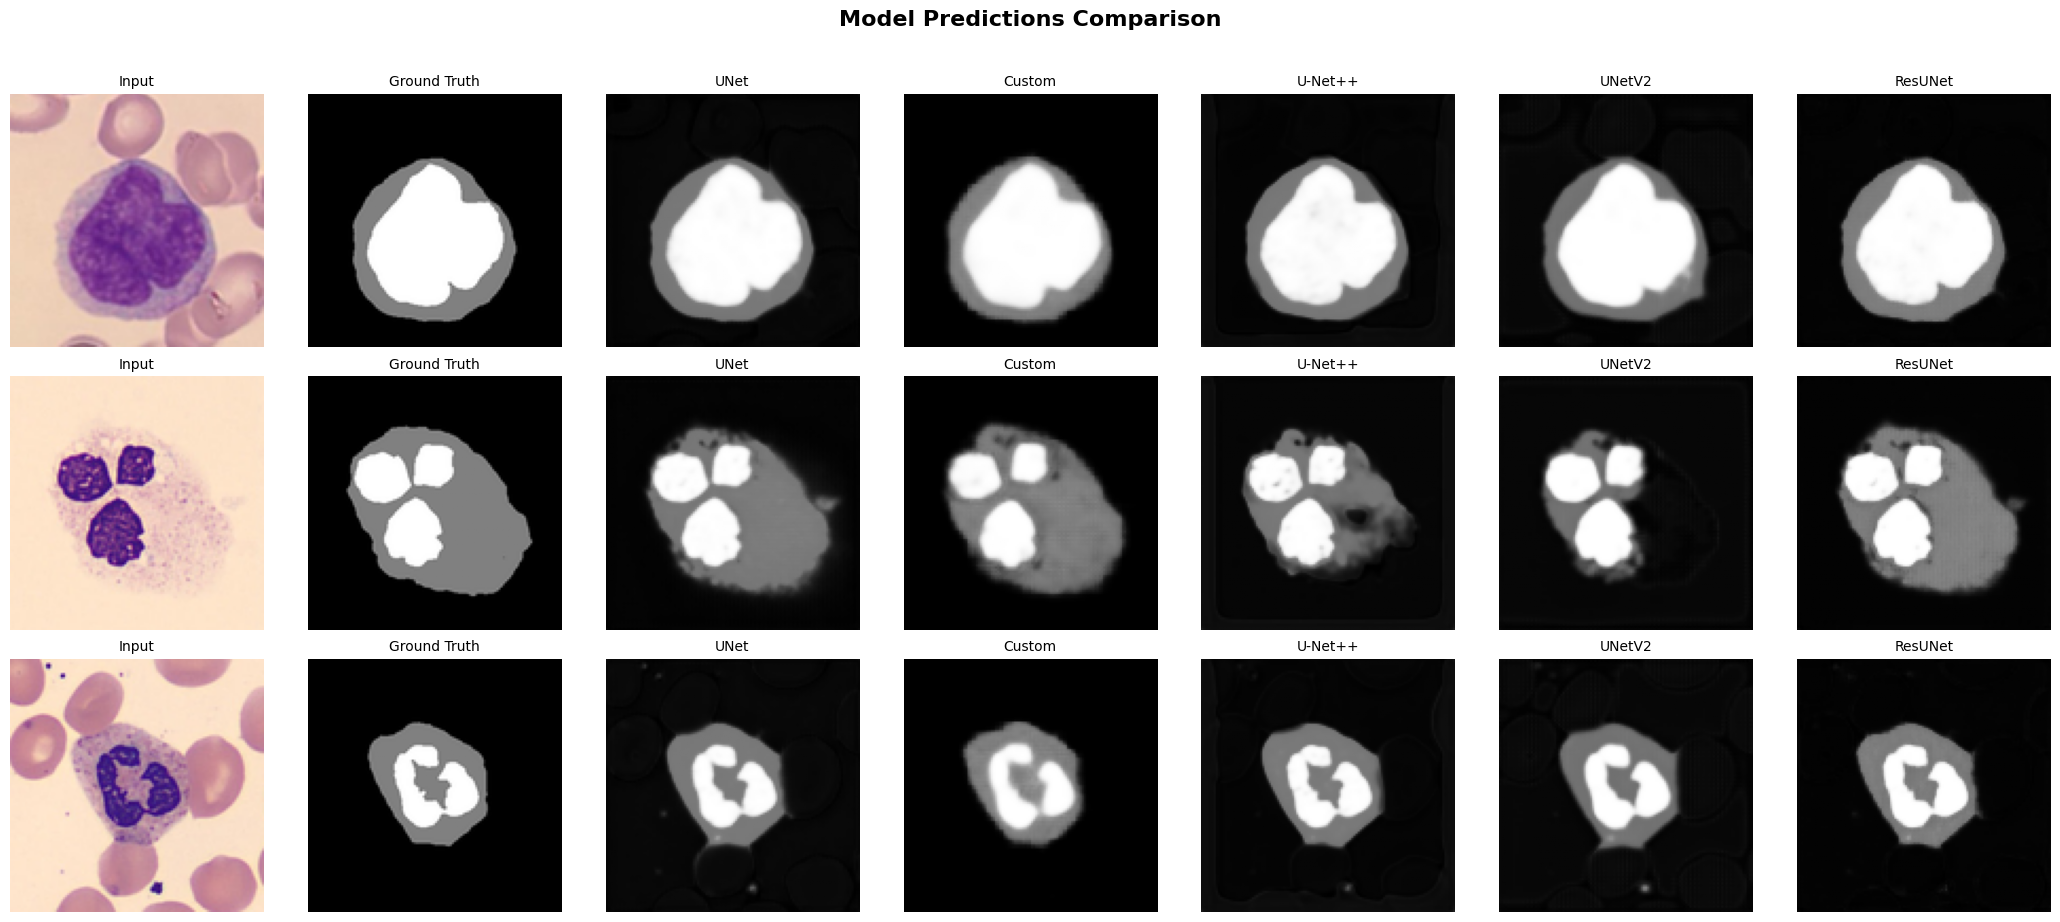

In [21]:
num_samples = 3
fig, axes = plt.subplots(num_samples, 7, figsize=(21, 3*num_samples))

with torch.no_grad():
    for i in range(num_samples):
        test_img = test_images[i:i+1].to(device)
        test_mask = test_masks[i:i+1].to(device)
        
        axes[i, 0].imshow(test_img[0].permute(1, 2, 0).cpu().numpy())
        axes[i, 0].set_title(f'Input', fontsize=10)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(test_mask[0, 0].cpu().numpy(), cmap='gray')
        axes[i, 1].set_title(f'Ground Truth', fontsize=10)
        axes[i, 1].axis('off')
        
        for idx, (name, res) in enumerate(results.items()):
            pred = torch.sigmoid(res['model'](test_img)).squeeze().cpu().numpy()
            axes[i, idx+2].imshow(pred, cmap='gray')
            axes[i, idx+2].set_title(f'{name}', fontsize=10)
            axes[i, idx+2].axis('off')

plt.suptitle('Model Predictions Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='summary'></a>
## 13. Summary

In [22]:
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"\nConfiguration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

print(f"\nModels Trained: {len(results)}")
print(f"\nBest Model by IoU: {best_iou_model[0]} (IoU = {best_iou_model[1]['iou']:.4f})")
print(f"Best Model by Dice: {best_dice_model[0]} (Dice = {best_dice_model[1]['dice']:.4f})")
print(f"Best Model by Accuracy: {best_acc_model[0]} (Accuracy = {best_acc_model[1]['accuracy']:.4f})")
print("=" * 80)

FINAL SUMMARY

Configuration:
  dataset: 2
  img_size: 120
  batch_size: 32
  epochs: 50
  learning_rate: 0.001
  base_filters: 32

Models Trained: 5

Best Model by IoU: Custom (IoU = 0.7241)
Best Model by Dice: Custom (Dice = 0.8400)
Best Model by Accuracy: Custom (Accuracy = 0.9334)
